<a href="https://colab.research.google.com/github/monteiro-sara/algorithmic_trading/blob/main/Time_Series_Stock_Price_Prediction_Risk_Analysis_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# A Time-Series Approach to Stock Price Prediction and Risk Analysis Using LSTM and Financial Metrics (10/10/2024)

**In this notebook, I will:**

* Fetch stock market data from Yahoo Finance using the yfinance library.
* Explore and visualize time-series stock data using Pandas, Matplotlib, and Seaborn.
* Analyze the correlation between different stocks.
* Assess the risk of investing in specific stocks by calculating various financial metrics.
* Use LSTM method to predict future stock prices

This approach will allow us to examine trends, relationships, and investment risks associated with the stocks under study.

**Rationale**

Time series works well with stock market datal, due to the serial time indexing ordering. We will look at technology stocks, like Apple, Amazon, Google and Microsoft). This will be done by fetching up-to-date data from yahoo finance, by using the yfinance library.

**Core questions** asked for the analysis are:
* How has the stock price evolved over time?
* What has been the stock's average daily return?
* What is the moving average of the different stocks over time?
* How are various stocks correlated with one another?
* What is the potential value at risk (VaR) for investing in a particular stock?
* How can we forecast future stock movements? (For example, predicting Apple Inc.'s closing price using a Long Short-Term Memory (LSTM) model).

**Data Retrieval:**

I downloaded stock data (e.g., open, close, volume) and stored it in DataFrames for each company.

* Descriptive Statistics: I computed basic statistics using .describe() to understand the central tendency and distribution of stock prices.
* Moving Averages: I calculated moving averages (10, 20, 50 days) to smooth out volatility and observe long-term trends.
Daily Returns: I computed daily percentage returns to assess volatility and risk.
* Correlation: I measured the correlation between different stocks to understand how they move in relation to one another.
* Risk Analysis: I visualized the expected return vs. risk using scatter plots based on mean and standard deviation of daily returns.
* Stock Price Prediction: I employed an LSTM (Long Short-Term Memory) model to predict Apple’s stock price based on historical data.

In [ ]:
!pip install yfinance --upgrade --no-cache-dir

Fetching the Data from the Yahoo library using yfinance

In [ ]:
import yfinance as yf

# Create a Ticker object for Microsoft
msft = yf.Ticker("MSFT")

# Get stock information
stock_info = msft.info
if 'longName' in stock_info:
    print(stock_info['longName'])
else:
    print("Stock name not available")

# Get historical market data
history = msft.history(period="1y")
print(history)

stock_name = msft.info['longName']
print(stock_name)  # Prints the full name of the stock, e.g., "Microsoft Corporation"

dividends = msft.dividends
if not dividends.empty:
    print(dividends)
else:
    print("No dividend data available")

Microsoft Corporation
                                 Open        High         Low       Close  \
Date                                                                        
2023-10-11 00:00:00-04:00  328.742444  330.340465  326.687888  329.943451   
2023-10-12 00:00:00-04:00  328.107209  331.144409  326.270986  328.692810   
2023-10-13 00:00:00-04:00  329.903711  331.342890  323.928542  325.288361   
2023-10-16 00:00:00-04:00  328.583593  333.635698  328.136964  330.161774   
2023-10-17 00:00:00-04:00  327.134521  330.975684  324.970770  329.586121   
...                               ...         ...         ...         ...   
2024-10-04 00:00:00-04:00  418.239990  419.750000  414.970001  416.059998   
2024-10-07 00:00:00-04:00  416.000000  417.109985  409.000000  409.540009   
2024-10-08 00:00:00-04:00  410.899994  415.660004  408.170013  414.709991   
2024-10-09 00:00:00-04:00  415.859985  420.380005  414.299988  417.459991   
2024-10-10 00:00:00-04:00  415.225006  417.350006  413

In [ ]:
import pandas as pd
pd.DataFrame(history).head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2023-10-11 00:00:00-04:00,328.742444,330.340465,326.687888,329.943451,20063200,0.0,0.0
2023-10-12 00:00:00-04:00,328.107209,331.144409,326.270986,328.692810,19313100,0.0,0.0
2023-10-13 00:00:00-04:00,329.903711,331.342890,323.928542,325.288361,21072400,0.0,0.0
2023-10-16 00:00:00-04:00,328.583593,333.635698,328.136964,330.161774,22158000,0.0,0.0
2023-10-17 00:00:00-04:00,327.134521,330.975684,324.970770,329.586121,18338500,0.0,0.0


In [ ]:
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
plt.style.use("fivethirtyeight")
%matplotlib inline

# For reading stock data from yahoo
from pandas_datareader.data import DataReader
import yfinance as yf
from pandas_datareader import data as pdr

# For time stamps
from datetime import datetime


# The tech stocks we'll use for this analysis
tech_list = ['AAPL', 'GOOG', 'MSFT', 'AMZN']

# Set up End and Start times for data grab
tech_list = ['AAPL', 'GOOG', 'MSFT', 'AMZN']

end = datetime.now()
start = datetime(end.year - 1, end.month, end.day)

for stock in tech_list:
    globals()[stock] = yf.download(stock, start, end)


company_list = [AAPL, GOOG, MSFT, AMZN]
company_name = ["APPLE", "GOOGLE", "MICROSOFT", "AMAZON"]

for company, com_name in zip(company_list, company_name):
    company["company_name"] = com_name

df = pd.concat(company_list, axis=0)
df.tail(10)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


,Open,High,Low,Close,Adj Close,Volume,company_name
Date,,,,,,,
2024-09-27,190.679993,190.899994,187.339996,187.970001,187.970001,36002300,AMAZON
2024-09-30,187.139999,188.490005,184.649994,186.330002,186.330002,41583900,AMAZON
2024-10-01,184.899994,186.190002,183.449997,185.130005,185.130005,36044900,AMAZON
2024-10-02,184.440002,186.600006,184.039993,184.759995,184.759995,23704100,AMAZON
2024-10-03,183.050003,183.440002,180.880005,181.960007,181.960007,30204300,AMAZON
2024-10-04,185.750000,187.600006,183.600006,186.509995,186.509995,40890300,AMAZON
2024-10-07,182.949997,183.600006,180.250000,180.800003,180.800003,42364200,AMAZON
2024-10-08,181.919998,183.089996,180.919998,182.720001,182.720001,26372100,AMAZON
2024-10-09,182.820007,185.850006,182.050003,185.169998,185.169998,26343100,AMAZON


In [ ]:
AAPL.describe()

,Open,High,Low,Close,Adj Close,Volume
count,253.000000,253.000000,253.000000,253.000000,253.000000,2.530000e+02
mean,195.588735,197.368656,193.913755,195.752016,195.327707,5.900514e+07
std,20.443949,20.679252,20.007283,20.413316,20.607364,2.988388e+07
min,165.350006,166.399994,164.080002,165.000000,164.585999,2.404830e+07
25%,179.860001,182.339996,178.970001,180.710007,179.790009,4.381660e+07
50%,190.470001,191.800003,189.229996,190.289993,189.770355,5.251700e+07
75%,216.539993,219.490005,214.619995,217.490005,217.238556,6.488540e+07
max,236.479996,237.229996,233.089996,234.820007,234.548523,3.186799e+08


In [ ]:
AAPL.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 253 entries, 2023-10-10 to 2024-10-10
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          253 non-null    float64
 1   High          253 non-null    float64
 2   Low           253 non-null    float64
 3   Close         253 non-null    float64
 4   Adj Close     253 non-null    float64
 5   Volume        253 non-null    int64  
 6   company_name  253 non-null    object 
dtypes: float64(5), int64(1), object(1)
memory usage: 15.8+ KB


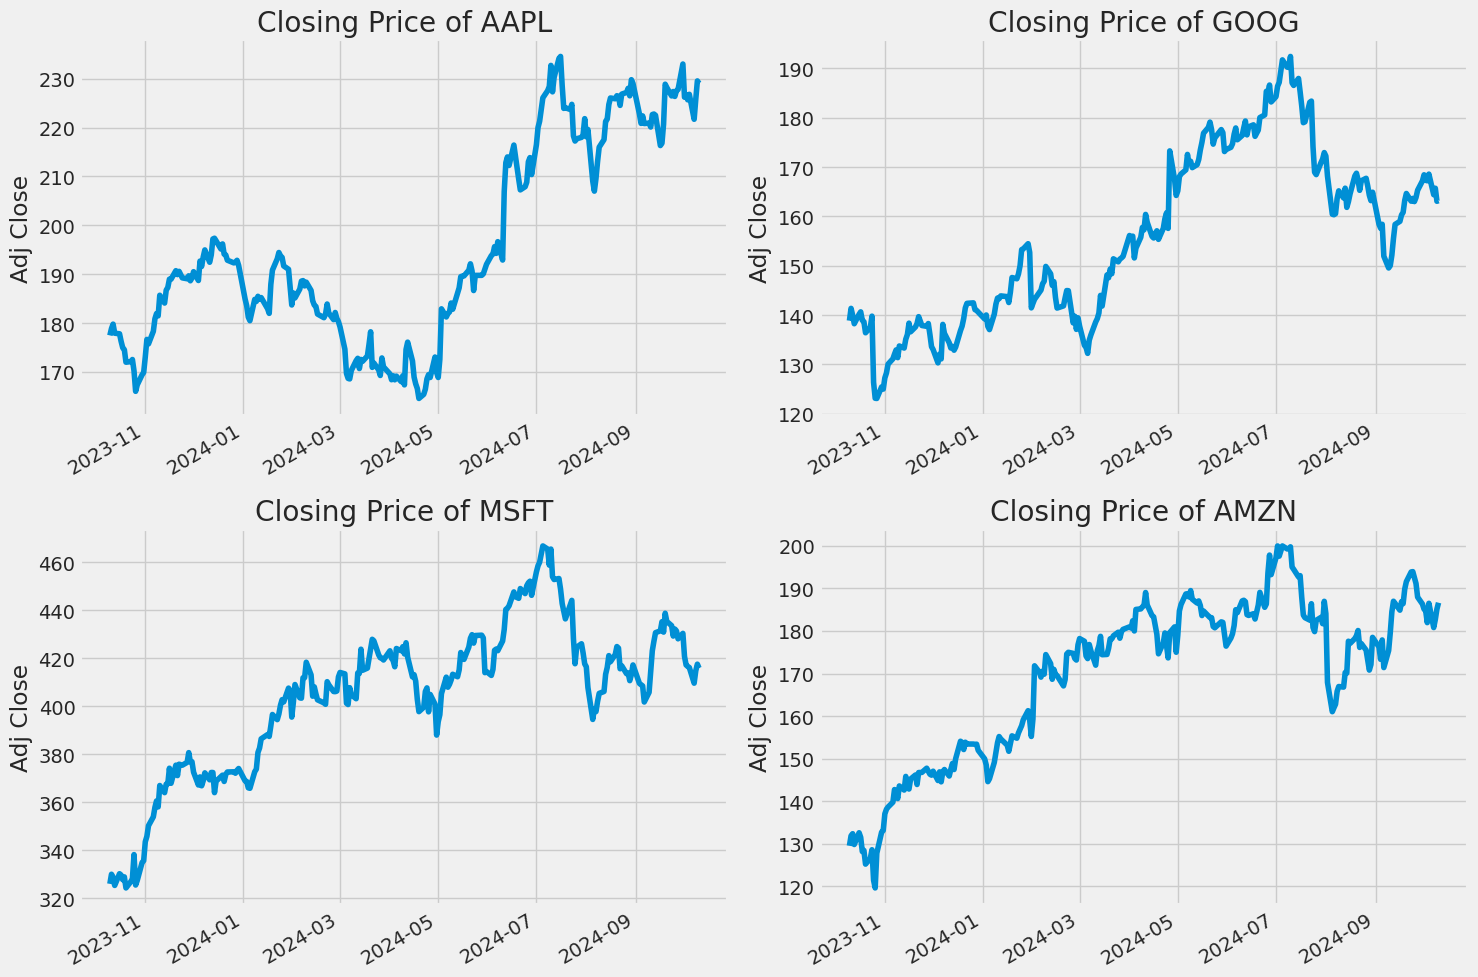

In [ ]:
#historical view of the closing price
plt.figure(figsize=(15, 10))
plt.subplots_adjust(top=1.25, bottom=1.2)

for i, company in enumerate(company_list, 1):
    plt.subplot(2, 2, i)
    company['Adj Close'].plot()
    plt.ylabel('Adj Close')
    plt.xlabel(None)
    plt.title(f"Closing Price of {tech_list[i - 1]}")

plt.tight_layout()

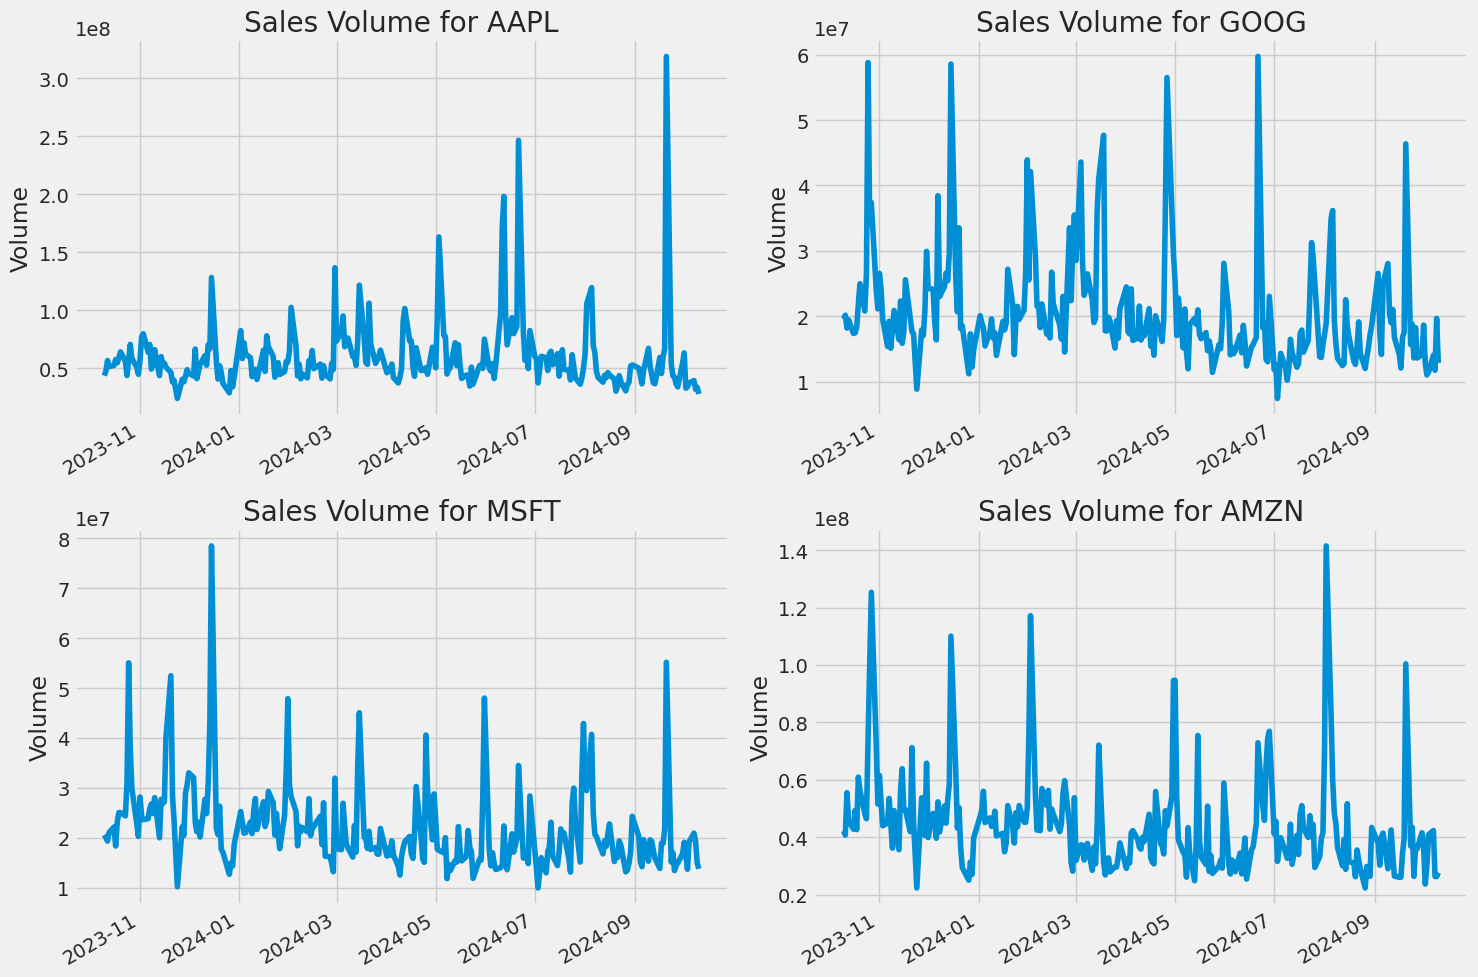

In [ ]:
#total volume of stock being traded each day
plt.figure(figsize=(15, 10))
plt.subplots_adjust(top=1.25, bottom=1.2)

for i, company in enumerate(company_list, 1):
    plt.subplot(2, 2, i)
    company['Volume'].plot()
    plt.ylabel('Volume')
    plt.xlabel(None)
    plt.title(f"Sales Volume for {tech_list[i - 1]}")

plt.tight_layout()

Text(0.5, 1.0, 'AMAZON')

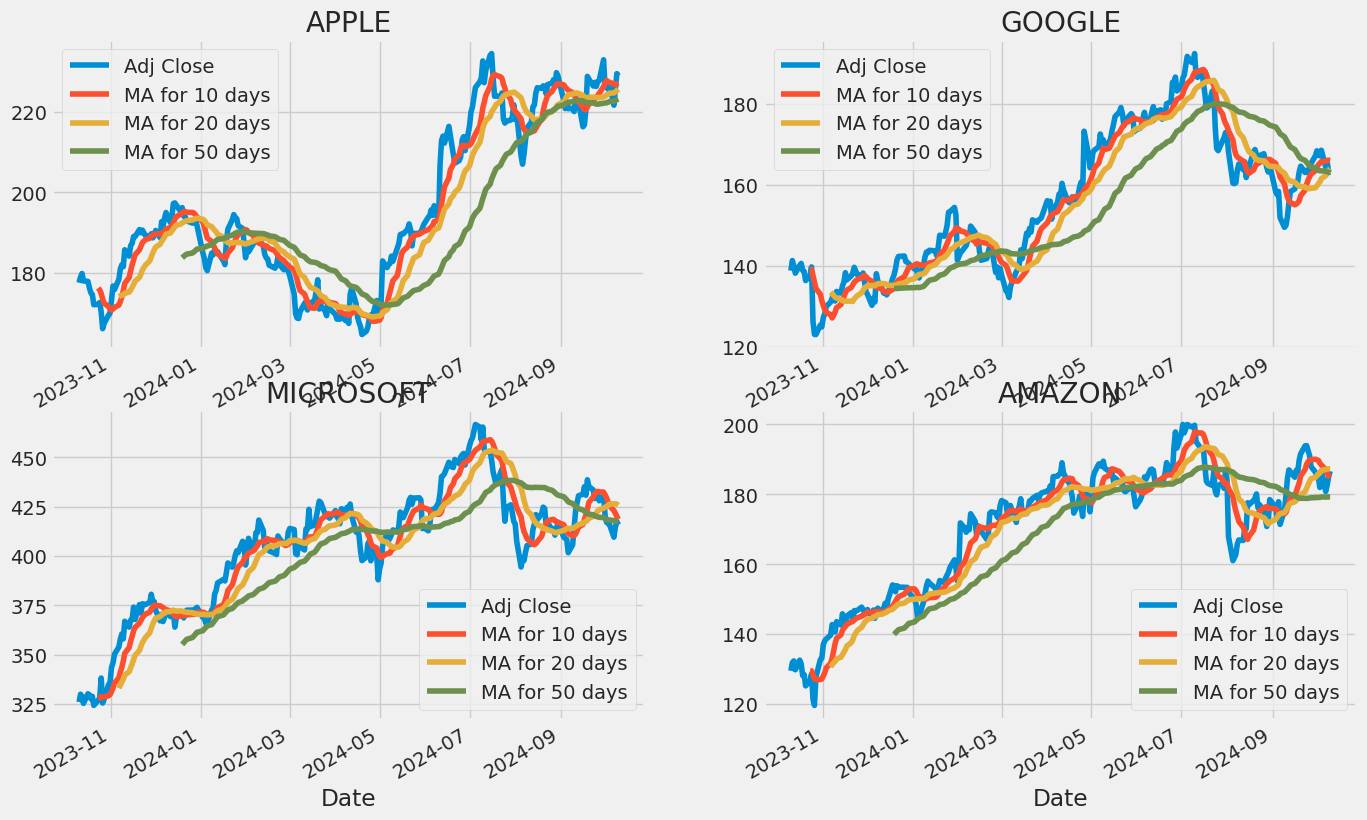

In [ ]:
ma_day = [10, 20, 50]

for ma in ma_day:
    for company in company_list:
        column_name = f"MA for {ma} days"
        company[column_name] = company['Adj Close'].rolling(ma).mean()


fig, axes = plt.subplots(nrows=2, ncols=2)
fig.set_figheight(10)
fig.set_figwidth(15)

AAPL[['Adj Close', 'MA for 10 days', 'MA for 20 days', 'MA for 50 days']].plot(ax=axes[0,0])
axes[0,0].set_title('APPLE')

GOOG[['Adj Close', 'MA for 10 days', 'MA for 20 days', 'MA for 50 days']].plot(ax=axes[0,1])
axes[0,1].set_title('GOOGLE')

MSFT[['Adj Close', 'MA for 10 days', 'MA for 20 days', 'MA for 50 days']].plot(ax=axes[1,0])
axes[1,0].set_title('MICROSOFT')

AMZN[['Adj Close', 'MA for 10 days', 'MA for 20 days', 'MA for 50 days']].plot(ax=axes[1,1])
axes[1,1].set_title('AMAZON')

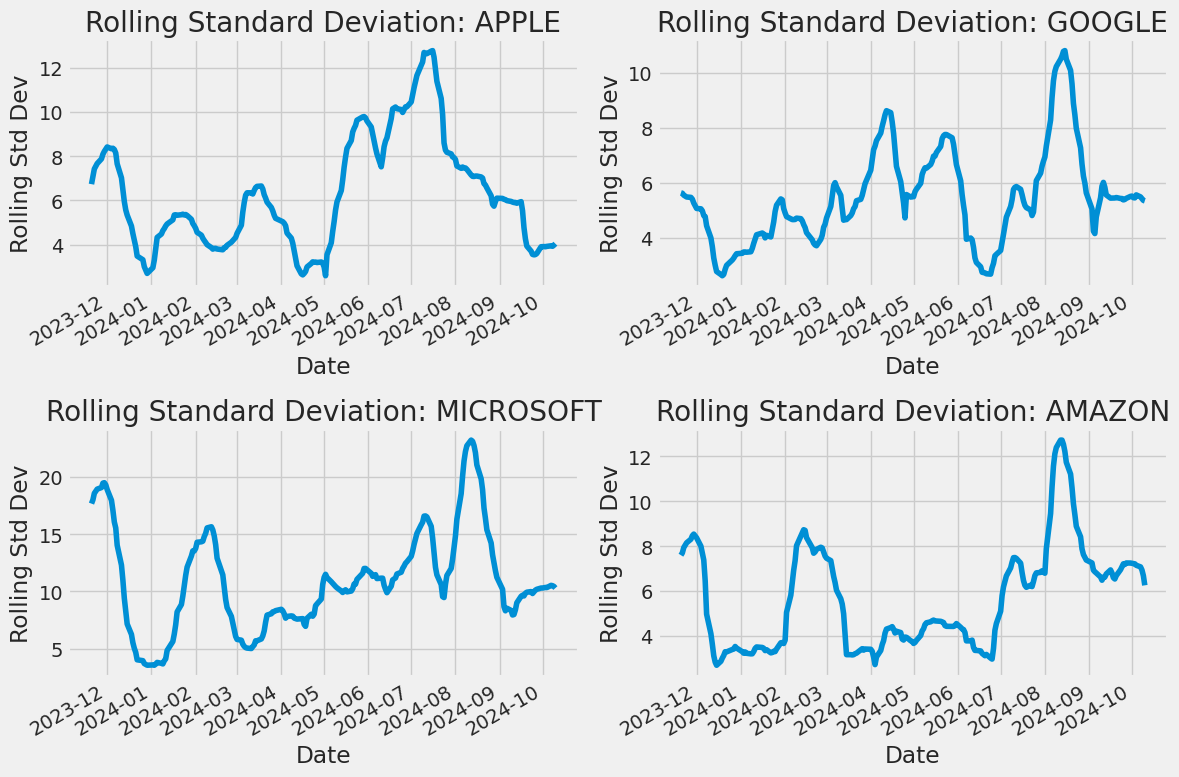

In [ ]:
#Rolling Standard Deviations (Volatility)
#To plot the rolling standard deviation of stock prices, place this code after calculating the moving averages:
# Rolling standard deviation (volatility) over a 30-day window
for company in company_list:
    company['Rolling Std Dev'] = company['Adj Close'].rolling(window=30).std()

# Plot rolling standard deviations
plt.figure(figsize=(12, 8))
for i, company in enumerate(company_list, 1):
    plt.subplot(2, 2, i)
    company['Rolling Std Dev'].plot()
    plt.ylabel('Rolling Std Dev')
    plt.title(f"Rolling Standard Deviation: {company_name[i - 1]}")
plt.tight_layout()

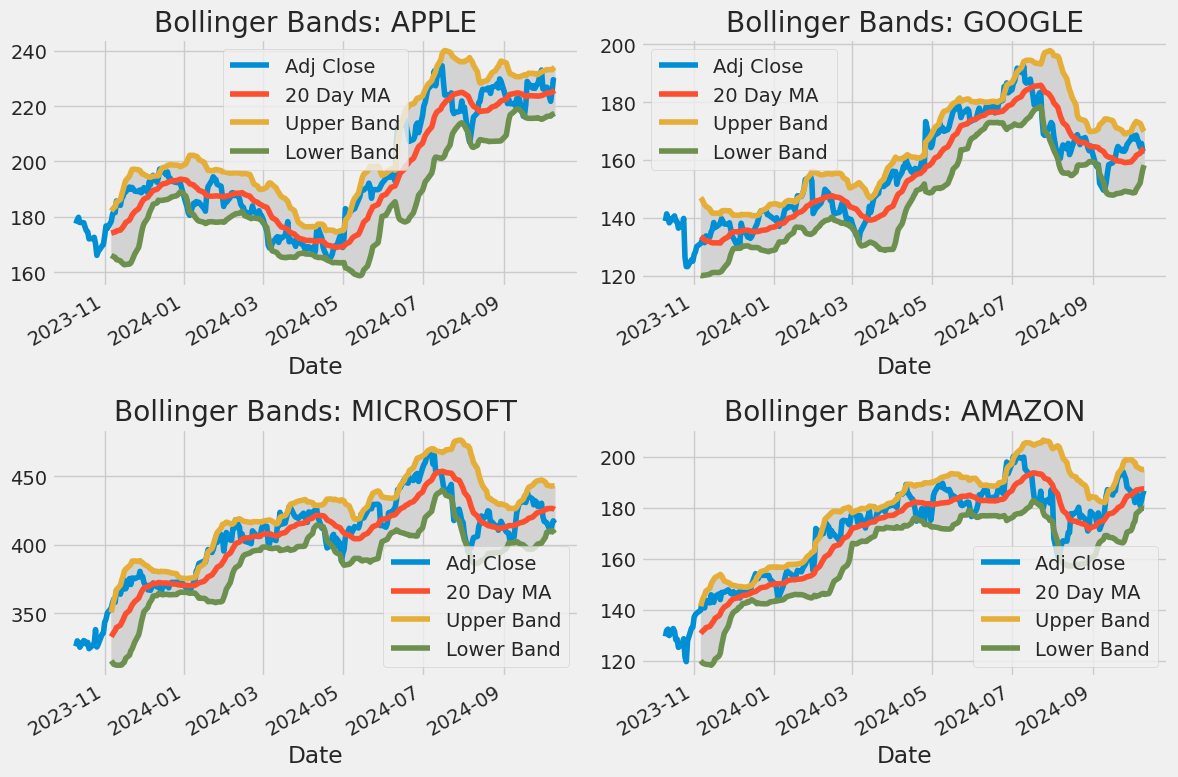

In [ ]:
# Calculate Bollinger Bands (20-day moving average and 2 standard deviations)
for company in company_list:
    company['20 Day MA'] = company['Adj Close'].rolling(window=20).mean()
    company['Upper Band'] = company['20 Day MA'] + (company['Adj Close'].rolling(window=20).std() * 2)
    company['Lower Band'] = company['20 Day MA'] - (company['Adj Close'].rolling(window=20).std() * 2)

# Plot Bollinger Bands
plt.figure(figsize=(12, 8))
for i, company in enumerate(company_list, 1):
    plt.subplot(2, 2, i)
    company[['Adj Close', '20 Day MA', 'Upper Band', 'Lower Band']].plot(ax=plt.gca())
    plt.fill_between(company.index, company['Upper Band'], company['Lower Band'], color='lightgray')
    plt.title(f"Bollinger Bands: {company_name[i - 1]}")
plt.tight_layout()


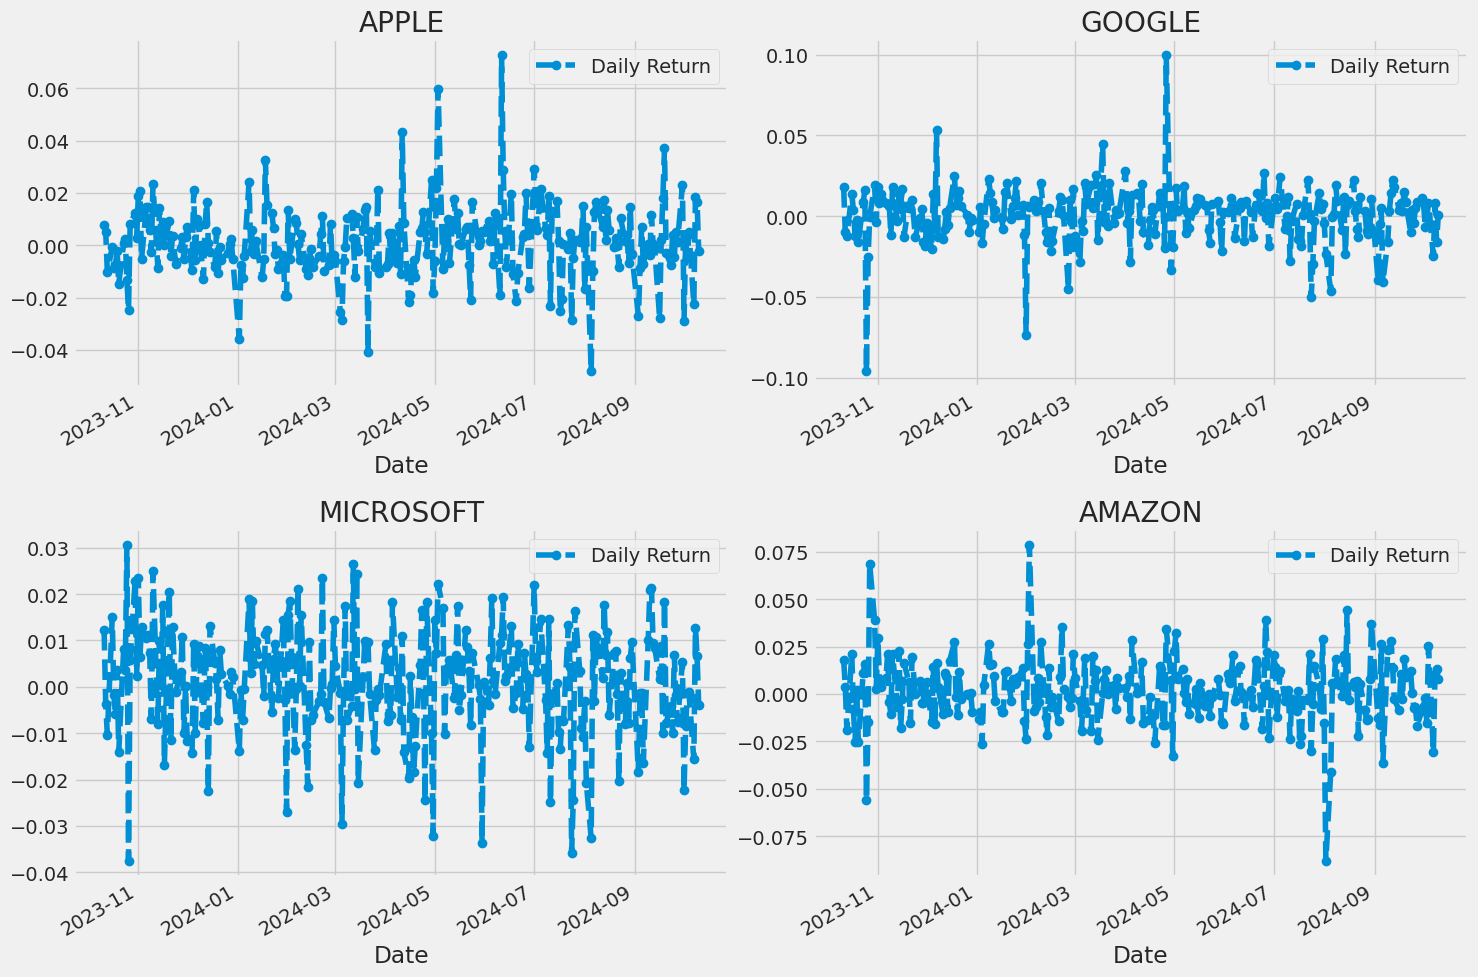

In [ ]:
# We'll use pct_change to find the percent change for each day
for company in company_list:
    company['Daily Return'] = company['Adj Close'].pct_change()

# Then we'll plot the daily return percentage
fig, axes = plt.subplots(nrows=2, ncols=2)
fig.set_figheight(10)
fig.set_figwidth(15)

AAPL['Daily Return'].plot(ax=axes[0,0], legend=True, linestyle='--', marker='o')
axes[0,0].set_title('APPLE')

GOOG['Daily Return'].plot(ax=axes[0,1], legend=True, linestyle='--', marker='o')
axes[0,1].set_title('GOOGLE')

MSFT['Daily Return'].plot(ax=axes[1,0], legend=True, linestyle='--', marker='o')
axes[1,0].set_title('MICROSOFT')

AMZN['Daily Return'].plot(ax=axes[1,1], legend=True, linestyle='--', marker='o')
axes[1,1].set_title('AMAZON')

fig.tight_layout()

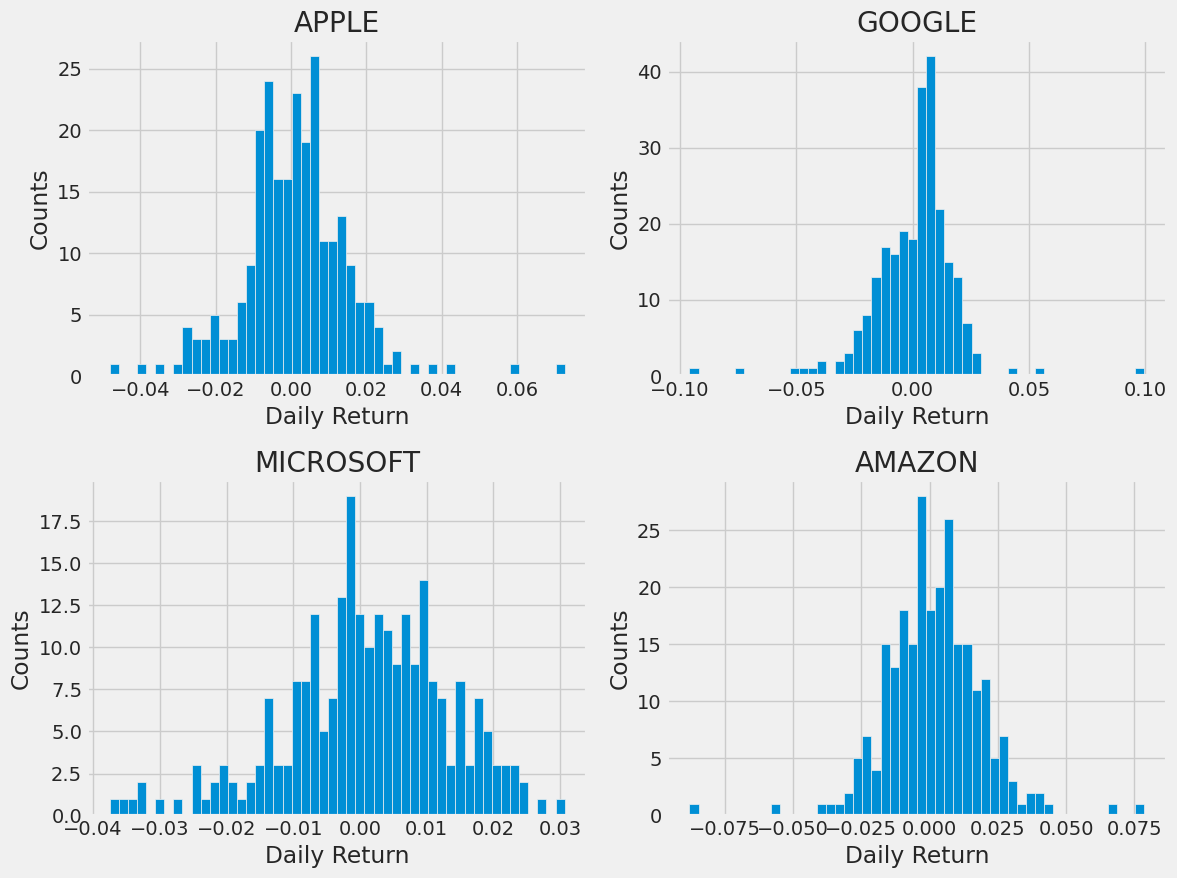

In [ ]:
plt.figure(figsize=(12, 9))

for i, company in enumerate(company_list, 1):
    plt.subplot(2, 2, i)
    company['Daily Return'].hist(bins=50)
    plt.xlabel('Daily Return')
    plt.ylabel('Counts')
    plt.title(f'{company_name[i - 1]}')

plt.tight_layout()

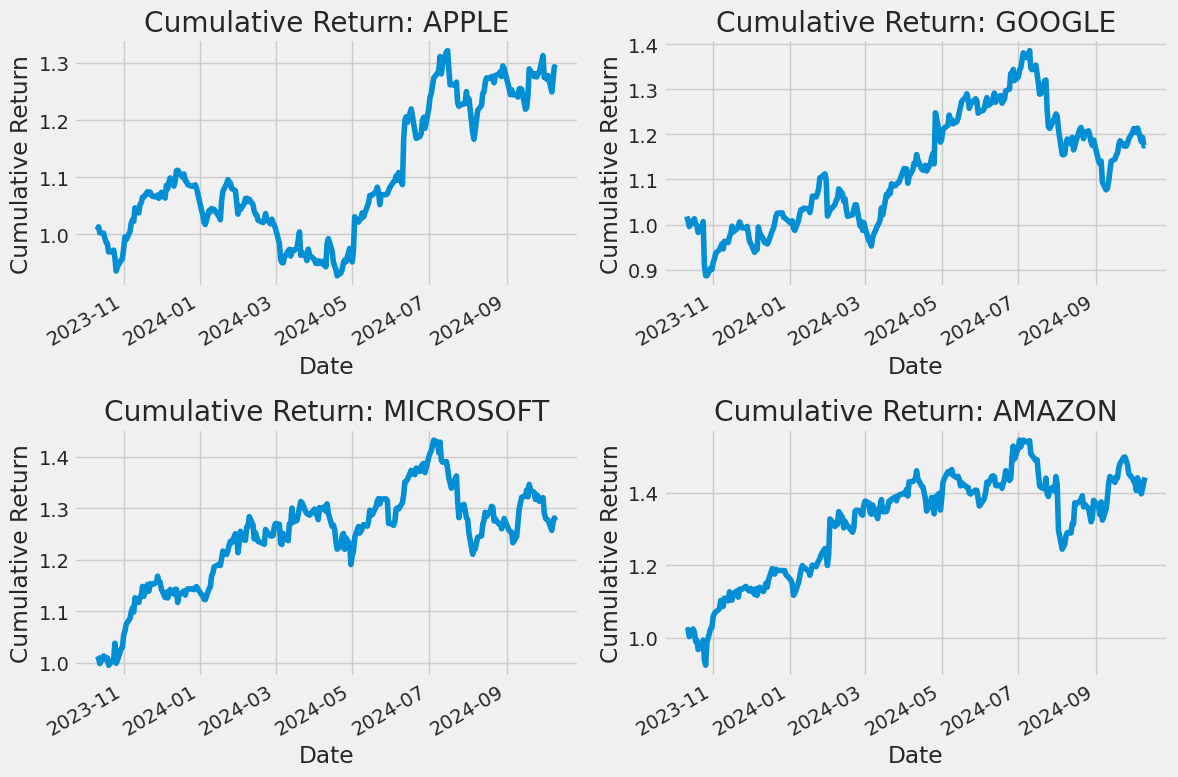

In [ ]:
# Calculate cumulative returns
for company in company_list:
    company['Cumulative Return'] = (1 + company['Daily Return']).cumprod()

# Plot cumulative returns
plt.figure(figsize=(12, 8))
for i, company in enumerate(company_list, 1):
    plt.subplot(2, 2, i)
    company['Cumulative Return'].plot()
    plt.ylabel('Cumulative Return')
    plt.title(f"Cumulative Return: {company_name[i - 1]}")
plt.tight_layout()


# Cumulative Returns
#Calculate cumulative returns to show long-term performance. Place this code after calculating daily returns:

In [ ]:
# Calculate Sharpe Ratio (Assuming risk-free rate is 0)
sharpe_ratios = {}
for company, name in zip(company_list, company_name):
    sharpe_ratios[name] = company['Daily Return'].mean() / company['Daily Return'].std()

# Display Sharpe Ratios
for name, ratio in sharpe_ratios.items():
    print(f"Sharpe Ratio for {name}: {ratio}")


Sharpe Ratio for APPLE: 0.07817371945629611
Sharpe Ratio for GOOGLE: 0.04541818668889411
Sharpe Ratio for MICROSOFT: 0.08479485345234099
Sharpe Ratio for AMAZON: 0.09126298771703065


* Amazon (0.0909) has the best risk-adjusted performance among the stocks, though still in the low range.
* Microsoft (0.0849) and Apple (0.0786) also perform reasonably well.
* Google (0.0456) shows the lowest, indicating relatively higher risk for its return.


All of the Sharpe Ratios are below 1, meaning these stocks offered positive returns, but with significant volatility, so they are not highly efficient in balancing risk and reward.

In [ ]:
# Fetch data for multiple tickers using yfinance
closing_df = yf.download(tech_list, start=start, end=end)['Adj Close']

# Calculate the returns
tech_rets = closing_df.pct_change()
tech_rets.head()


[*********************100%***********************]  4 of 4 completed


Ticker,AAPL,AMZN,GOOG,MSFT
Date,,,,
2023-10-10 00:00:00+00:00,NaN,NaN,NaN,NaN
2023-10-11 00:00:00+00:00,0.007904,0.018150,0.017960,0.012272
2023-10-12 00:00:00+00:00,0.005061,0.003793,-0.009951,-0.003790
2023-10-13 00:00:00+00:00,-0.010293,-0.019195,-0.012189,-0.010357
2023-10-16 00:00:00+00:00,-0.000727,0.021265,0.013783,0.014982


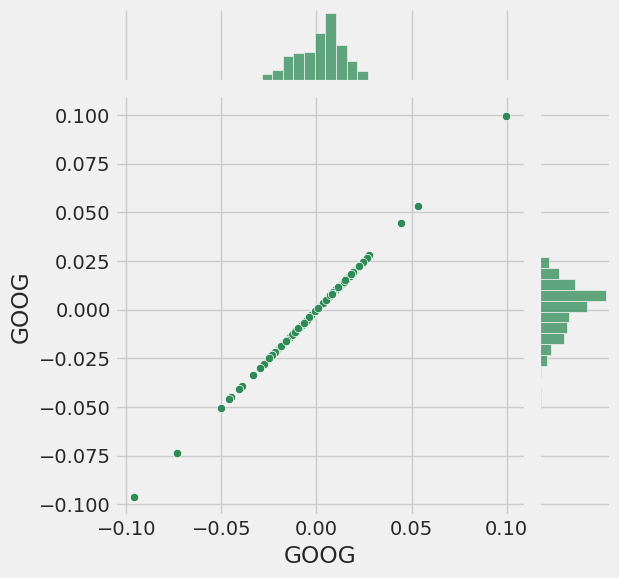

In [ ]:
# Comparing Google to itself should show a perfectly linear relationship
sns.jointplot(x='GOOG', y='GOOG', data=tech_rets, kind='scatter', color='seagreen')

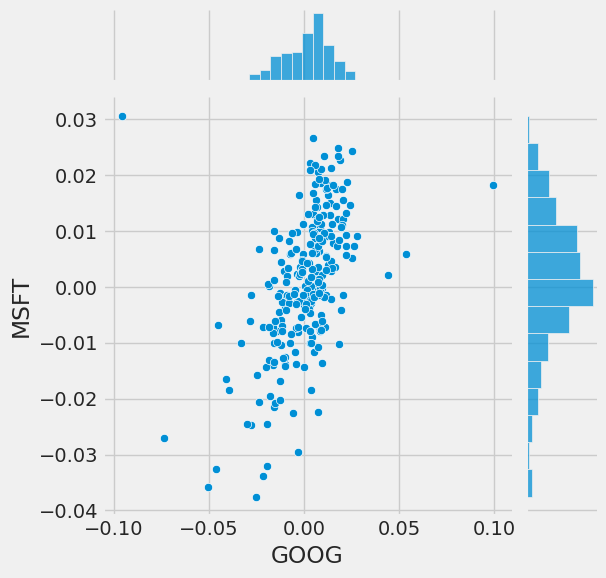

In [ ]:
# We'll use joinplot to compare the daily returns of Google and Microsoft
sns.jointplot(x='GOOG', y='MSFT', data=tech_rets, kind='scatter')

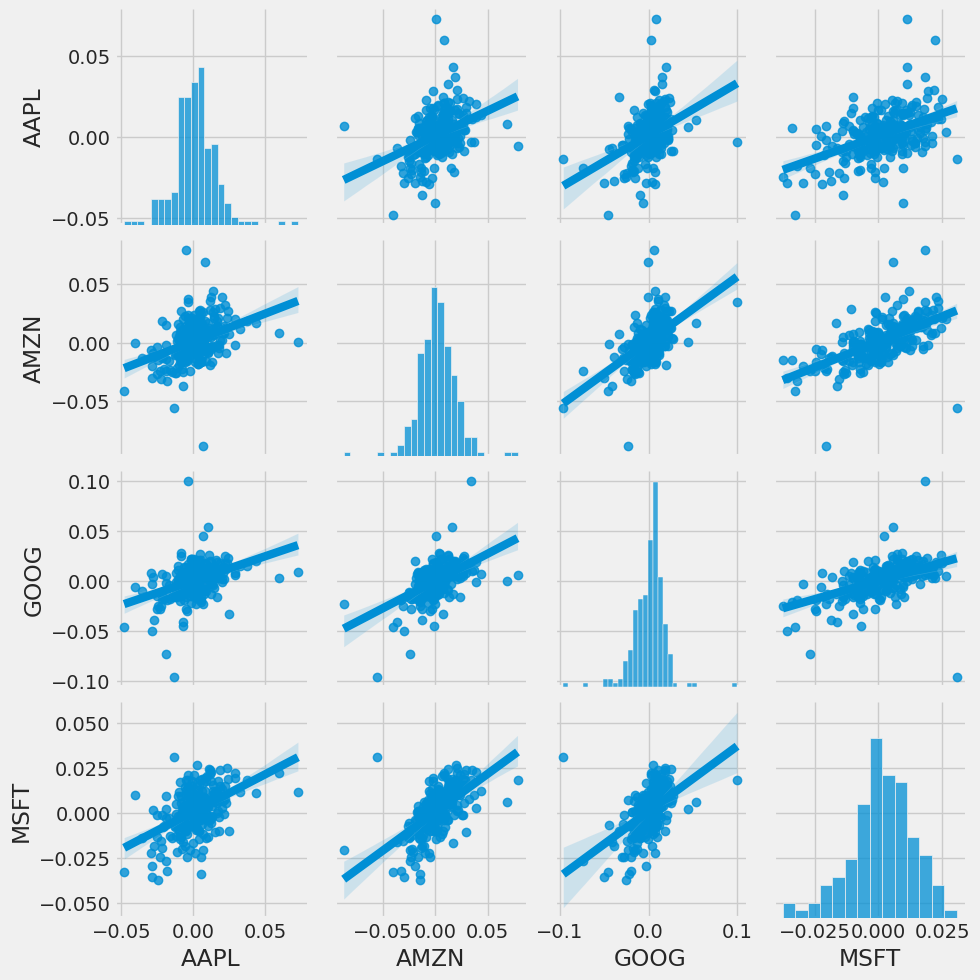

In [ ]:
# We can simply call pairplot on our DataFrame for an automatic visual analysis
# of all the comparisons

sns.pairplot(tech_rets, kind='reg')

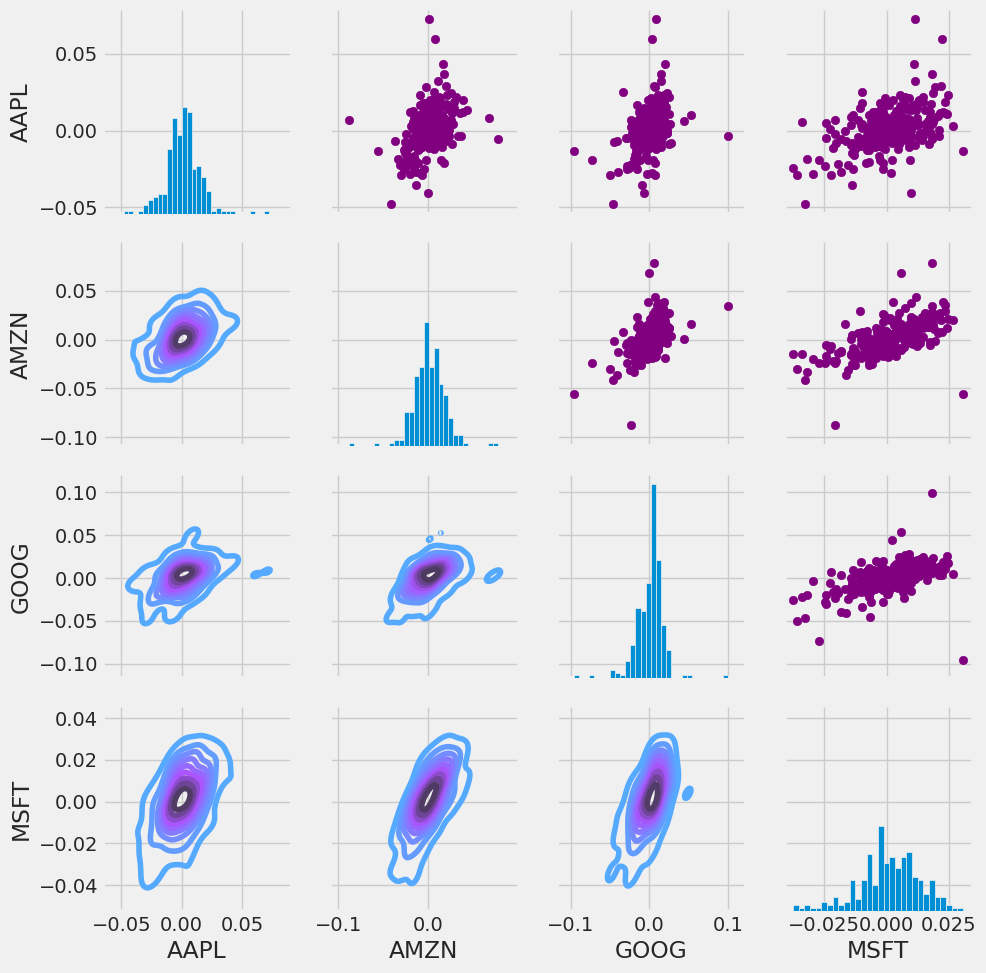

In [ ]:
# Set up our figure by naming it returns_fig, call PairPLot on the DataFrame
return_fig = sns.PairGrid(tech_rets.dropna())

# Using map_upper we can specify what the upper triangle will look like.
return_fig.map_upper(plt.scatter, color='purple')

# We can also define the lower triangle in the figure, inclufing the plot type (kde)
# or the color map (BluePurple)
return_fig.map_lower(sns.kdeplot, cmap='cool_d')

# Finally we'll define the diagonal as a series of histogram plots of the daily return
return_fig.map_diag(plt.hist, bins=30)

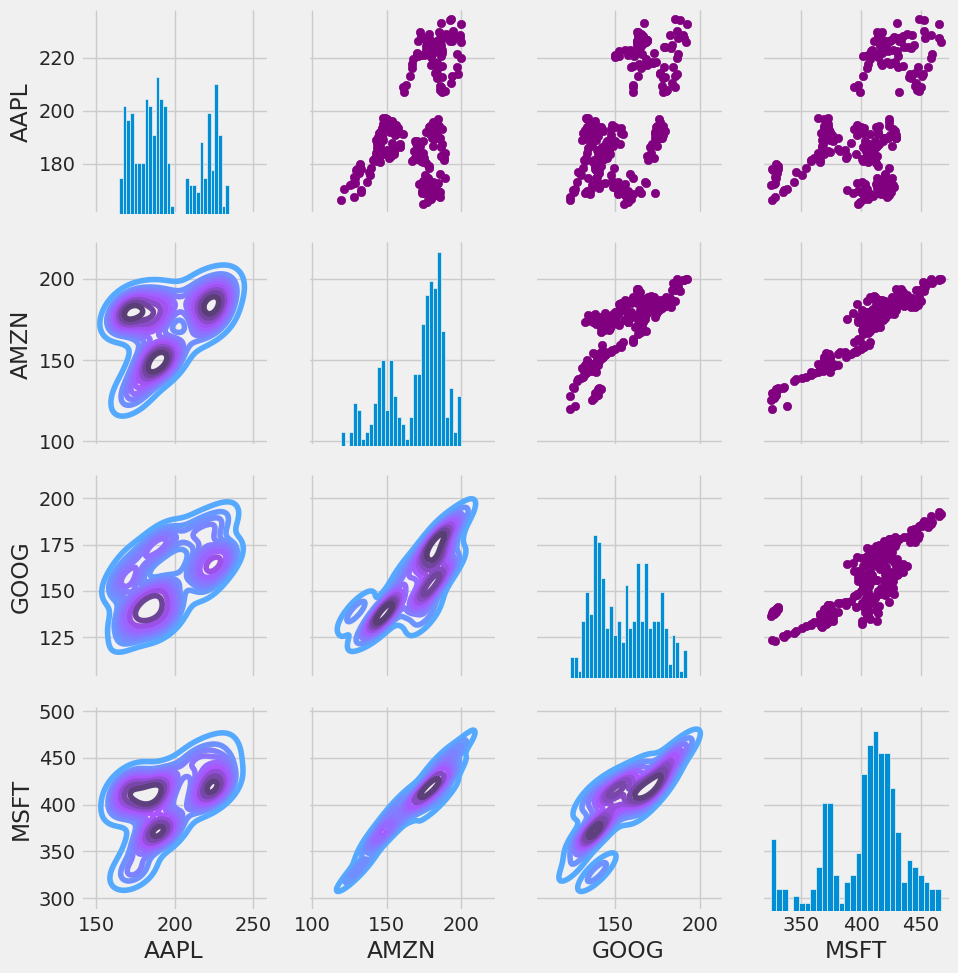

In [ ]:
# Set up our figure by naming it returns_fig, call PairPLot on the DataFrame
returns_fig = sns.PairGrid(closing_df)

# Using map_upper we can specify what the upper triangle will look like.
returns_fig.map_upper(plt.scatter,color='purple')

# We can also define the lower triangle in the figure, inclufing the plot type (kde) or the color map (BluePurple)
returns_fig.map_lower(sns.kdeplot,cmap='cool_d')

# Finally we'll define the diagonal as a series of histogram plots of the daily return
returns_fig.map_diag(plt.hist,bins=30)

Text(0.5, 1.0, 'Correlation of stock closing price')

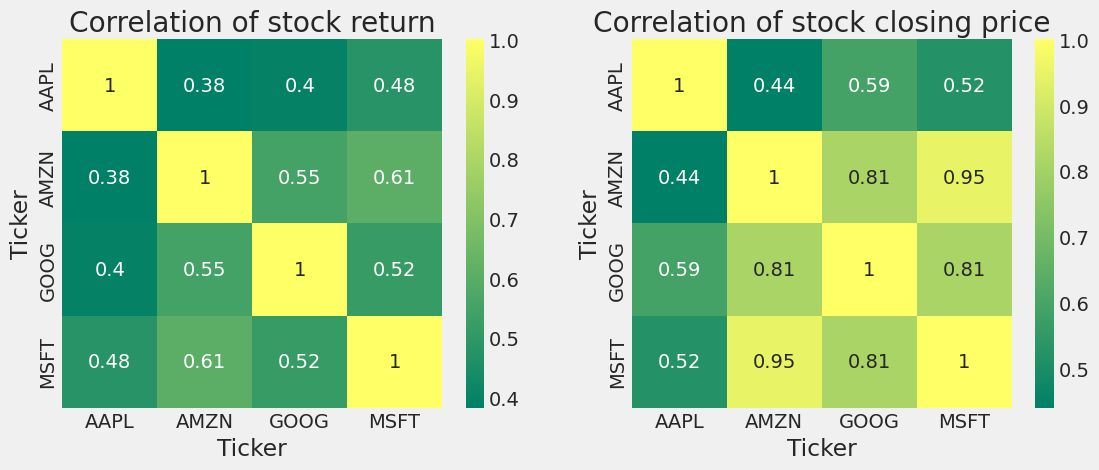

In [ ]:
plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
sns.heatmap(tech_rets.corr(), annot=True, cmap='summer')
plt.title('Correlation of stock return')

plt.subplot(2, 2, 2)
sns.heatmap(closing_df.corr(), annot=True, cmap='summer')
plt.title('Correlation of stock closing price')

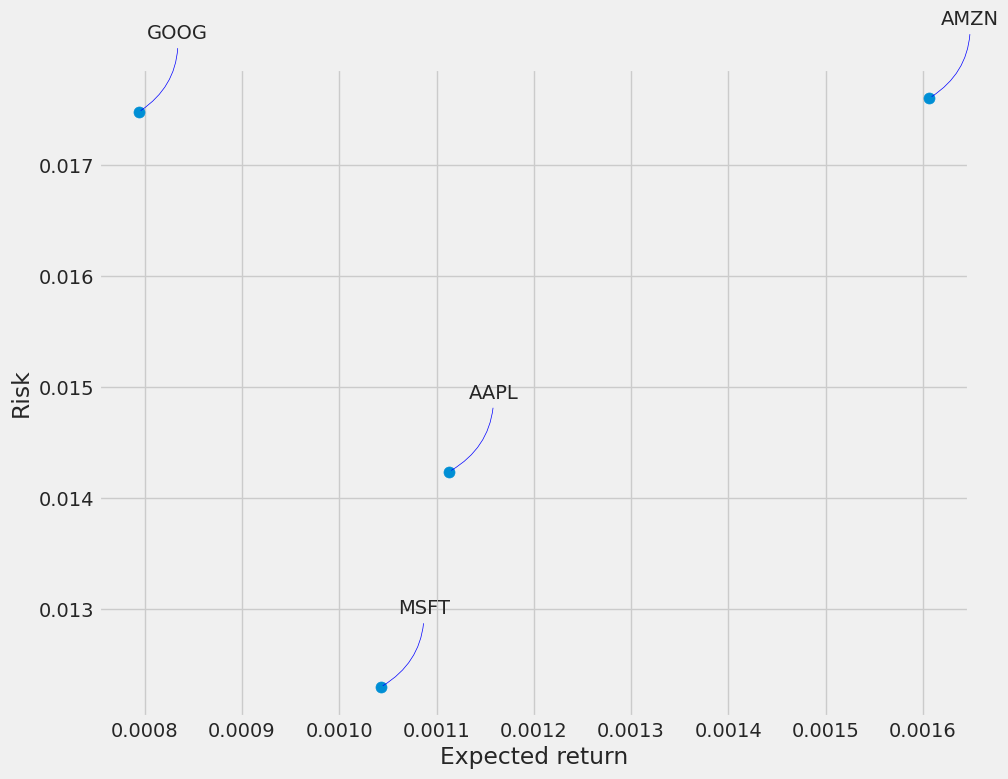

In [ ]:
rets = tech_rets.dropna()

area = np.pi * 20

plt.figure(figsize=(10, 8))
plt.scatter(rets.mean(), rets.std(), s=area)
plt.xlabel('Expected return')
plt.ylabel('Risk')

for label, x, y in zip(rets.columns, rets.mean(), rets.std()):
    plt.annotate(label, xy=(x, y), xytext=(50, 50), textcoords='offset points', ha='right', va='bottom',
                 arrowprops=dict(arrowstyle='-', color='blue', connectionstyle='arc3,rad=-0.3'))

In [ ]:
from datetime import datetime

# Fetch AAPL stock data using yfinance
df = yf.download('AAPL', start='2012-01-01', end=datetime.now())

# Show the data
print(df)

[*********************100%***********************]  1 of 1 completed

                  Open        High         Low       Close   Adj Close  \
Date                                                                     
2012-01-03   14.621429   14.732143   14.607143   14.686786   12.402626   
2012-01-04   14.642857   14.810000   14.617143   14.765714   12.469279   
2012-01-05   14.819643   14.948214   14.738214   14.929643   12.607710   
2012-01-06   14.991786   15.098214   14.972143   15.085714   12.739513   
2012-01-09   15.196429   15.276786   15.048214   15.061786   12.719304   
...                ...         ...         ...         ...         ...   
2024-10-04  227.899994  228.000000  224.130005  226.800003  226.800003   
2024-10-07  224.500000  225.690002  221.330002  221.690002  221.690002   
2024-10-08  224.300003  225.979996  223.250000  225.770004  225.770004   
2024-10-09  225.229996  229.750000  224.830002  229.539993  229.539993   
2024-10-10  227.779999  229.500000  227.169998  229.039993  229.039993   

               Volume  
Date         

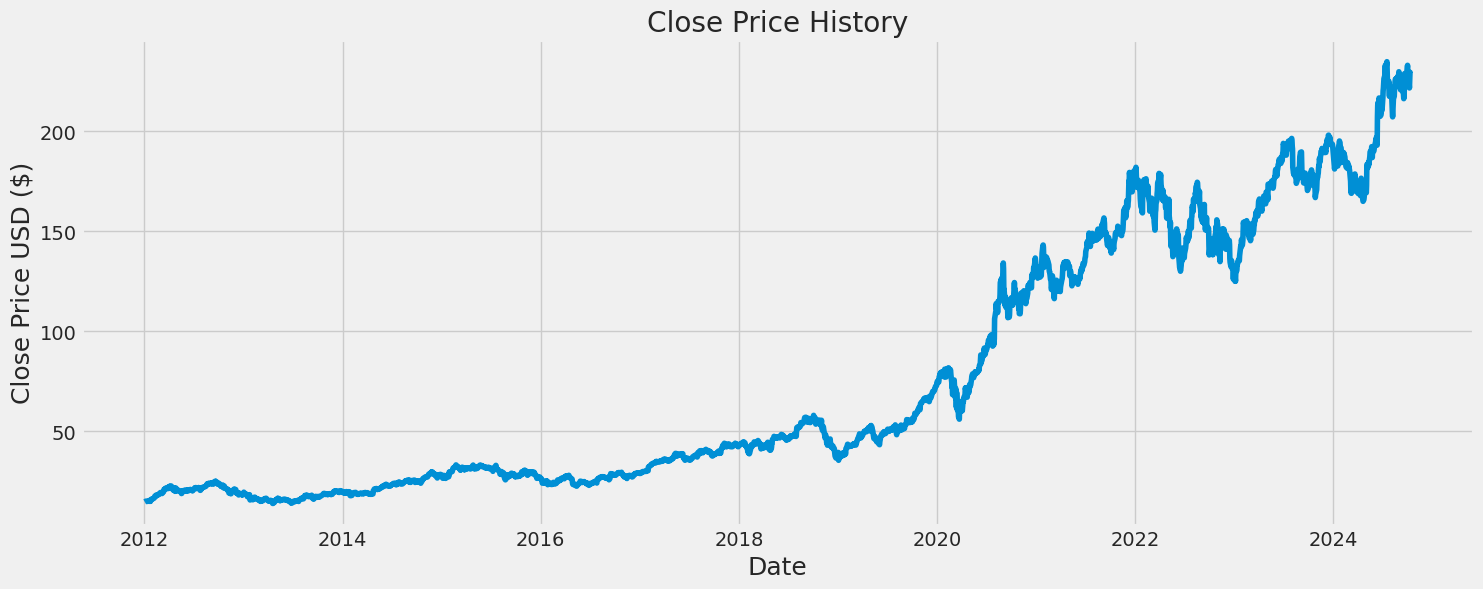

In [ ]:
plt.figure(figsize=(16,6))
plt.title('Close Price History')
plt.plot(df['Close'])
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)
plt.show()

In [ ]:
# Create a new dataframe with only the 'Close column
data = df.filter(['Close'])
# Convert the dataframe to a numpy array
dataset = data.values
# Get the number of rows to train the model on
training_data_len = int(np.ceil( len(dataset) * .95 ))

training_data_len

3054

In [ ]:
# Scale the data
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(dataset)

scaled_data

array([[0.00334711],
       [0.00370446],
       [0.00444665],
       ...,
       [0.95902612],
       [0.97609474],
       [0.97383099]])

In [ ]:
# Create the training data set
# Create the scaled training data set
train_data = scaled_data[0:int(training_data_len), :]
# Split the data into x_train and y_train data sets
x_train = []
y_train = []

for i in range(60, len(train_data)):
    x_train.append(train_data[i-60:i, 0])
    y_train.append(train_data[i, 0])
    if i<= 61:
        print(x_train)
        print(y_train)
        print()

# Convert the x_train and y_train to numpy arrays
x_train, y_train = np.array(x_train), np.array(y_train)

# Reshape the data
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))
# x_train.shape

[array([0.00334711, 0.00370446, 0.00444665, 0.00515326, 0.00504493,
       0.00528909, 0.00517752, 0.00498995, 0.00473447, 0.00552516,
       0.00623825, 0.00601834, 0.0048137 , 0.00596336, 0.00483149,
       0.00907602, 0.00874778, 0.00917627, 0.01010279, 0.01066387,
       0.01061698, 0.01044397, 0.0111813 , 0.01187498, 0.01266083,
       0.01393014, 0.01659652, 0.01663694, 0.01812132, 0.01923055,
       0.01732415, 0.01805825, 0.0180437 , 0.0201021 , 0.01980942,
       0.0203511 , 0.02132451, 0.0218662 , 0.02342657, 0.02456329,
       0.02489154, 0.02500635, 0.02306276, 0.02259383, 0.02266337,
       0.02449054, 0.02500473, 0.02610912, 0.02871243, 0.03218567,
       0.03153564, 0.03153726, 0.03404841, 0.03483426, 0.03427478,
       0.03376382, 0.03323184, 0.03499918, 0.03621191, 0.03671963])]
[0.03546486572351548]

[array([0.00334711, 0.00370446, 0.00444665, 0.00515326, 0.00504493,
       0.00528909, 0.00517752, 0.00498995, 0.00473447, 0.00552516,
       0.00623825, 0.00601834, 0.00

In [ ]:
from keras.models import Sequential
from keras.layers import Dense, LSTM

# Build the LSTM model
model = Sequential()
model.add(LSTM(128, return_sequences=True, input_shape= (x_train.shape[1], 1)))
model.add(LSTM(64, return_sequences=False))
model.add(Dense(25))
model.add(Dense(1))

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
model.fit(x_train, y_train, batch_size=1, epochs=1)

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2994/2994 ━━━━━━━━━━━━━━━━━━━━ 176s 57ms/step - loss: 0.0021


In [ ]:
# Create the testing data set
# Create a new array containing scaled values from index 1543 to 2002
test_data = scaled_data[training_data_len - 60: , :]
# Create the data sets x_test and y_test
x_test = []
y_test = dataset[training_data_len:, :]
for i in range(60, len(test_data)):
    x_test.append(test_data[i-60:i, 0])

# Convert the data to a numpy array
x_test = np.array(x_test)

# Reshape the data
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1 ))

# Get the models predicted price values
predictions = model.predict(x_test)
predictions = scaler.inverse_transform(predictions)

# Get the root mean squared error (RMSE)
rmse = np.sqrt(np.mean(((predictions - y_test) ** 2)))
rmse

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


6.977918280735659

<ipython-input-97-821e2a77ef2b>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['Predictions'] = predictions


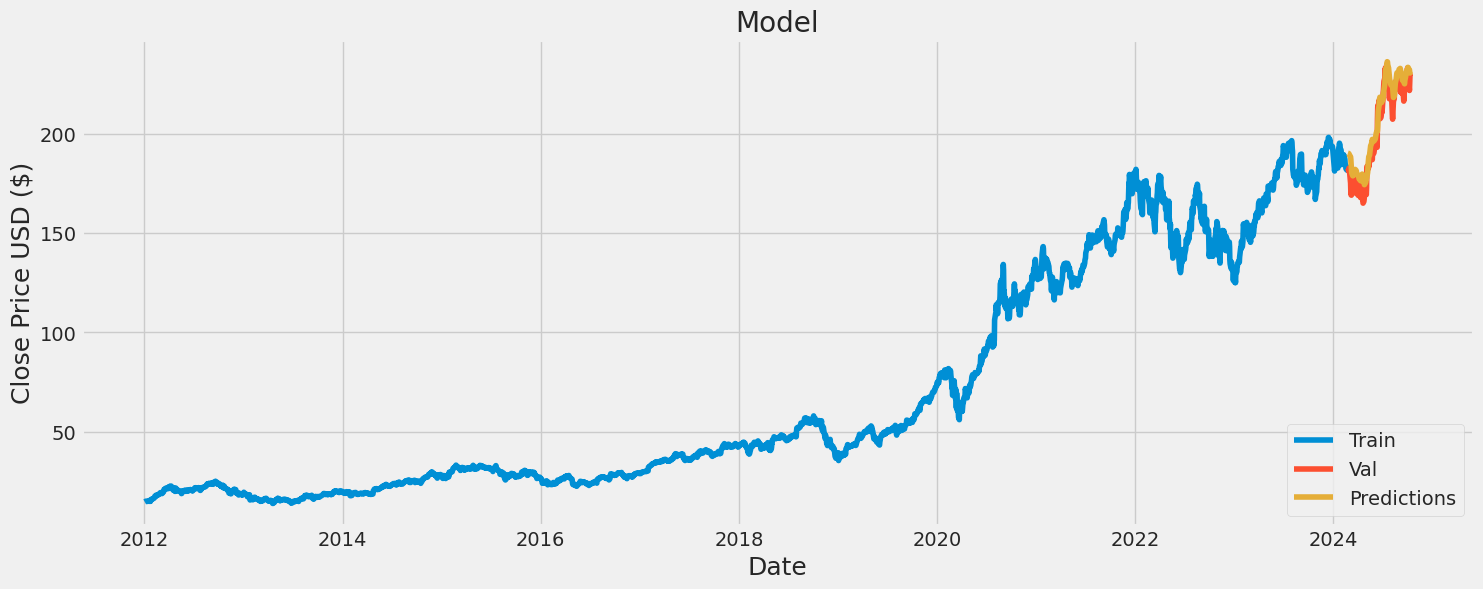

In [ ]:
#plot data
train = data[:training_data_len]
valid = data[training_data_len:]
valid['Predictions'] = predictions

#visualize plot
plt.figure(figsize=(16,6))
plt.title('Model')
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)
plt.plot(train['Close'])
plt.plot(valid[['Close', 'Predictions']])
plt.legend(['Train', 'Val', 'Predictions'], loc='lower right')
plt.show()

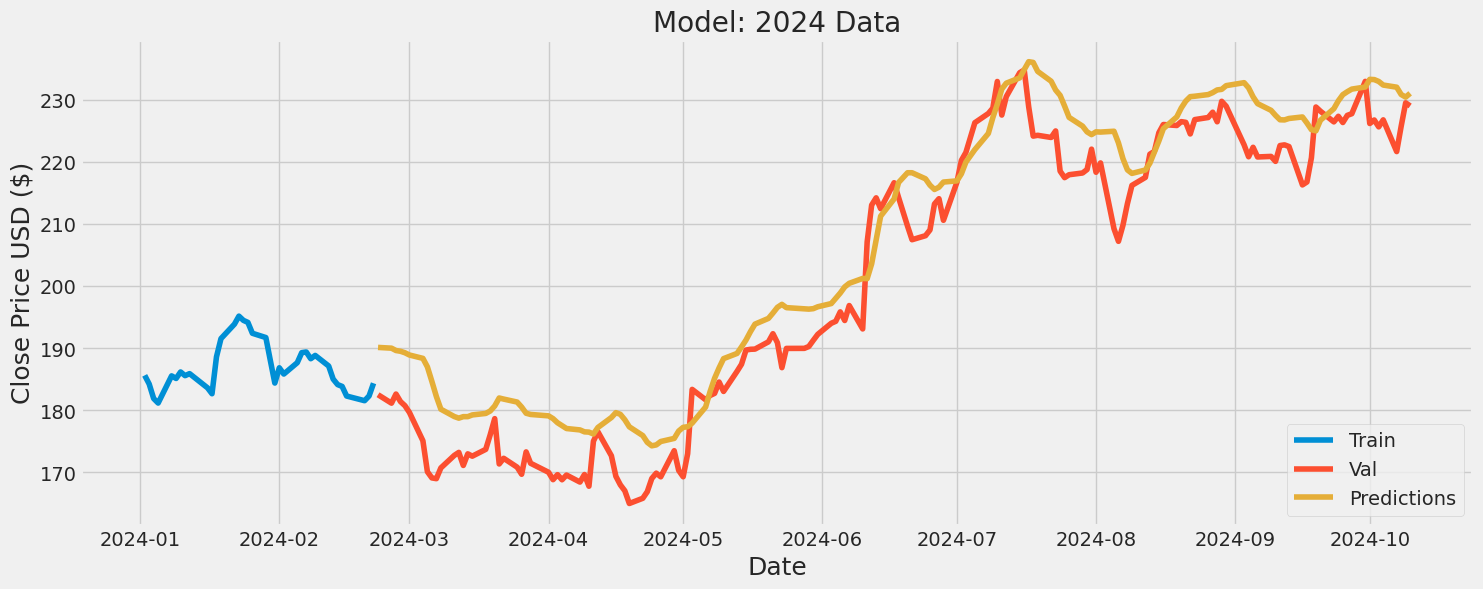

In [ ]:
#close-up 2024

#filter plot
train_2024 = train[train.index.year == 2024]
valid_2024 = valid[valid.index.year == 2024]

#visualize plot
plt.figure(figsize=(16,6))
plt.title('Model: 2024 Data')
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)
plt.plot(train_2024['Close'])
plt.plot(valid_2024[['Close', 'Predictions']])
plt.legend(['Train', 'Val', 'Predictions'], loc='lower right')
plt.show()

In [ ]:
# Show the valid and predicted prices
valid

,Close,Predictions
Date,,
2024-02-23,182.520004,190.142258
2024-02-26,181.160004,190.020538
2024-02-27,182.630005,189.640976
2024-02-28,181.419998,189.522568
2024-02-29,180.750000,189.279526
...,...,...
2024-10-04,226.800003,232.405121
2024-10-07,221.690002,232.061707
2024-10-08,225.770004,230.880508


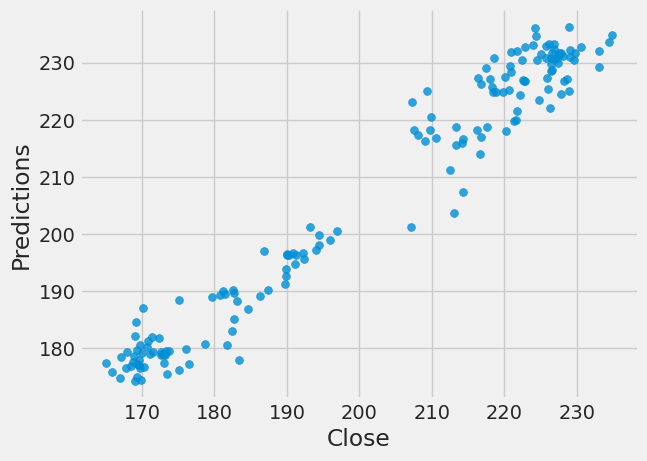

In [ ]:
# @title Close vs Predictions

from matplotlib import pyplot as plt
valid.plot(kind='scatter', x='Close', y='Predictions', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)